In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import itertools

In [12]:
%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']='Malgun Gothic'

In [2]:
df_x = pd.read_csv('../../DB/x_변수병합_민주.csv', encoding='CP949')
df_y = pd.read_csv('../../DB/폐기물데이터_행정구역변경_2.csv', encoding='CP949')

- 8차와 동일한 점: Y값 = 종량제방식 등 혼합배출로 동일
# 1. 부산 제외 전국 데이터로 train 80%, test 20% 예측은 부산으로만
# 2. randomforest 진행시 회귀분석용데이터와 raw데이터와 비교하기기

In [3]:
y_1 = df_y[df_y['폐기물_종류'] == '종량제방식 등 혼합배출'].groupby(['행정구역','연도'])[['발생량']].sum().reset_index()
y_1

,행정구역,연도,발생량
0,강원_강릉시,2019,38945.5
1,강원_강릉시,2020,40579.7
2,강원_강릉시,2021,42722.3
3,강원_강릉시,2022,40274.5
4,강원_강릉시,2023,37047.4
...,...,...,...
1140,충북_충주시,2019,82052.0
1141,충북_충주시,2020,60127.2
1142,충북_충주시,2021,56905.0
1143,충북_충주시,2022,41319.7


In [4]:
y_1 = y_1[~(y_1['발생량'] == 0)]
# 855	전남_담양군	2019	0.0

In [5]:
y_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, 0 to 1144
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   행정구역    1144 non-null   object 
 1   연도      1144 non-null   int64  
 2   발생량     1144 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 35.8+ KB


In [6]:
df_merged = pd.merge(df_x, y_1, on=['행정구역', '연도'], how='inner')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   행정구역          1144 non-null   object 
 1   시도            1144 non-null   object 
 2   시군구           1144 non-null   object 
 3   연도            1144 non-null   int64  
 4   주민등록세대수       1144 non-null   int64  
 5   총인구수          1144 non-null   int64  
 6   단독주택-계        1144 non-null   int64  
 7   아파트           1144 non-null   int64  
 8   연립주택          1144 non-null   int64  
 9   다세대주택         1144 non-null   int64  
 10  비주거용 건물 내 주택  1144 non-null   int64  
 11  단독주택비율        1144 non-null   float64
 12  아파트비율         1144 non-null   float64
 13  연립주택비율        1144 non-null   float64
 14  다세대주택비율       1144 non-null   float64
 15  비주거용주택비율      1144 non-null   float64
 16  1인가구          1144 non-null   int64  
 17  2인가구          1144 non-null   int64  
 18  3인가구          1144 non-null 

In [7]:
df_merged.isnull().sum()

행정구역            0
시도              0
시군구             0
연도              0
주민등록세대수         0
총인구수            0
단독주택-계          0
아파트             0
연립주택            0
다세대주택           0
비주거용 건물 내 주택    0
단독주택비율          0
아파트비율           0
연립주택비율          0
다세대주택비율         0
비주거용주택비율        0
1인가구            0
2인가구            0
3인가구            0
4인가구            0
5인이상가구          0
총전입             0
총전출             0
순이동             0
발생량             0
dtype: int64

In [8]:
# 비율로 변경
df_merged['1인가구비율'] = df_merged['1인가구'] / (df_merged['1인가구']+ df_merged['2인가구']+ df_merged['3인가구'] + df_merged['4인가구'] + df_merged['5인이상가구'])
df_merged['2인가구비율'] = df_merged['2인가구'] / (df_merged['1인가구']+ df_merged['2인가구']+ df_merged['3인가구'] + df_merged['4인가구'] + df_merged['5인이상가구'])
df_merged['3인가구비율'] = df_merged['3인가구'] / (df_merged['1인가구']+ df_merged['2인가구']+ df_merged['3인가구'] + df_merged['4인가구'] + df_merged['5인이상가구'])
df_merged['4인가구비율'] = df_merged['4인가구'] / (df_merged['1인가구']+ df_merged['2인가구']+ df_merged['3인가구'] + df_merged['4인가구'] + df_merged['5인이상가구'])
df_merged['5인이상가구비율'] = df_merged['5인이상가구'] / (df_merged['1인가구']+ df_merged['2인가구']+ df_merged['3인가구'] + df_merged['4인가구'] + df_merged['5인이상가구'])
df_merged.head(3)

,행정구역,시도,시군구,연도,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,다세대주택,...,5인이상가구,총전입,총전출,순이동,발생량,1인가구비율,2인가구비율,3인가구비율,4인가구비율,5인이상가구비율
0,강원_강릉시,강원,강릉시,2019,99086,213442,29481,50175,2919,1470,...,3715.0,31980,30787,1193,38945.5,0.348767,0.310871,0.179677,0.120346,0.040340
1,강원_고성군,강원,고성군,2019,14445,27260,8764,2193,109,121,...,409.0,3096,3835,-739,10402.5,0.343424,0.366152,0.165649,0.088034,0.036741
2,강원_동해시,강원,동해시,2019,41141,90522,10461,24961,1657,1152,...,1580.0,10516,11039,-523,29090.5,0.291131,0.333738,0.198045,0.133457,0.043630


In [38]:
# 선정 피처
print(df_merged.columns)
df_merged = df_merged[['행정구역','연도', '총인구수',
                         '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
                         '1인가구비율', '2인가구비율', '3인가구비율', '4인가구비율', '5인이상가구비율',
                         '총전입', '순이동', '발생량']]
print(df_merged.info())

Index(['행정구역', '시도', '시군구', '연도', '주민등록세대수', '총인구수', '단독주택-계', '아파트', '연립주택',
       '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
       '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입', '총전출',
       '순이동', '발생량', '1인가구비율', '2인가구비율', '3인가구비율', '4인가구비율', '5인이상가구비율'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   행정구역      1144 non-null   object 
 1   연도        1144 non-null   int64  
 2   총인구수      1144 non-null   int64  
 3   단독주택비율    1144 non-null   float64
 4   아파트비율     1144 non-null   float64
 5   연립주택비율    1144 non-null   float64
 6   다세대주택비율   1144 non-null   float64
 7   비주거용주택비율  1144 non-null   float64
 8   1인가구비율    1144 non-null   float64
 9   2인가구비율    1144 non-null   float64
 10  3인가구비율    1144 non-null   float64
 11  4인가구비율    1144 non-null   float64
 12  5인이상가구비율  1144 non-nu

# 데이터 확인

In [39]:
predict_busan = df_merged[(df_merged['행정구역'].str.startswith('부산')) & (df_merged['연도'] == 2023)].reset_index(drop=True)
predict_busan

,행정구역,연도,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,1인가구비율,2인가구비율,3인가구비율,4인가구비율,5인이상가구비율,총전입,순이동,발생량
0,부산_강서구,2023,142396,0.1790,0.7894,0.0068,0.0159,0.0090,0.305750,0.267591,0.207005,0.176826,0.042828,15487,-1203,17160.4
1,부산_금정구,2023,215590,0.1773,0.5656,0.0347,0.2080,0.0144,0.400460,0.295430,0.174782,0.104118,0.025210,20637,-4379,32190.5
2,부산_기장군,2023,178729,0.1167,0.7977,0.0202,0.0554,0.0101,0.308858,0.295872,0.203270,0.152192,0.039808,16324,450,30226.6
3,부산_남구,2023,254185,0.1380,0.6197,0.0274,0.2068,0.0082,0.359557,0.298420,0.188417,0.123890,0.029717,33024,-998,31821.2
4,부산_동구,2023,87792,0.3651,0.4649,0.0282,0.1270,0.0149,0.435892,0.302896,0.156451,0.082502,0.022260,13396,1932,14990.3
5,부산_동래구,2023,270815,0.1136,0.7114,0.0265,0.1366,0.0119,0.312375,0.296712,0.209838,0.148640,0.032435,27804,-1603,25182.0
6,부산_부산진구,2023,359508,0.1352,0.7039,0.0115,0.1410,0.0084,0.416489,0.289246,0.167671,0.102080,0.024514,50717,4821,60952.1
7,부산_북구,2023,273596,0.0637,0.8211,0.0210,0.0882,0.0061,0.316077,0.310469,0.208453,0.134569,0.030432,21630,-4464,27999.9
8,부산_사상구,2023,202932,0.1126,0.7620,0.0097,0.1050,0.0106,0.386925,0.299987,0.177031,0.109632,0.026425,21791,142,19262.1
9,부산_사하구,2023,297831,0.1361,0.7122,0.0419,0.1017,0.0082,0.352247,0.307482,0.192628,0.119458,0.028185,27826,-2852,40109.1


In [54]:
df_merged_1 = df_merged[~((df_merged['행정구역'].str.startswith('부산')) & (df_merged['연도'] == 2023))].reset_index(drop=True)
df_merged_1.set_index(['행정구역','연도'], inplace=True)

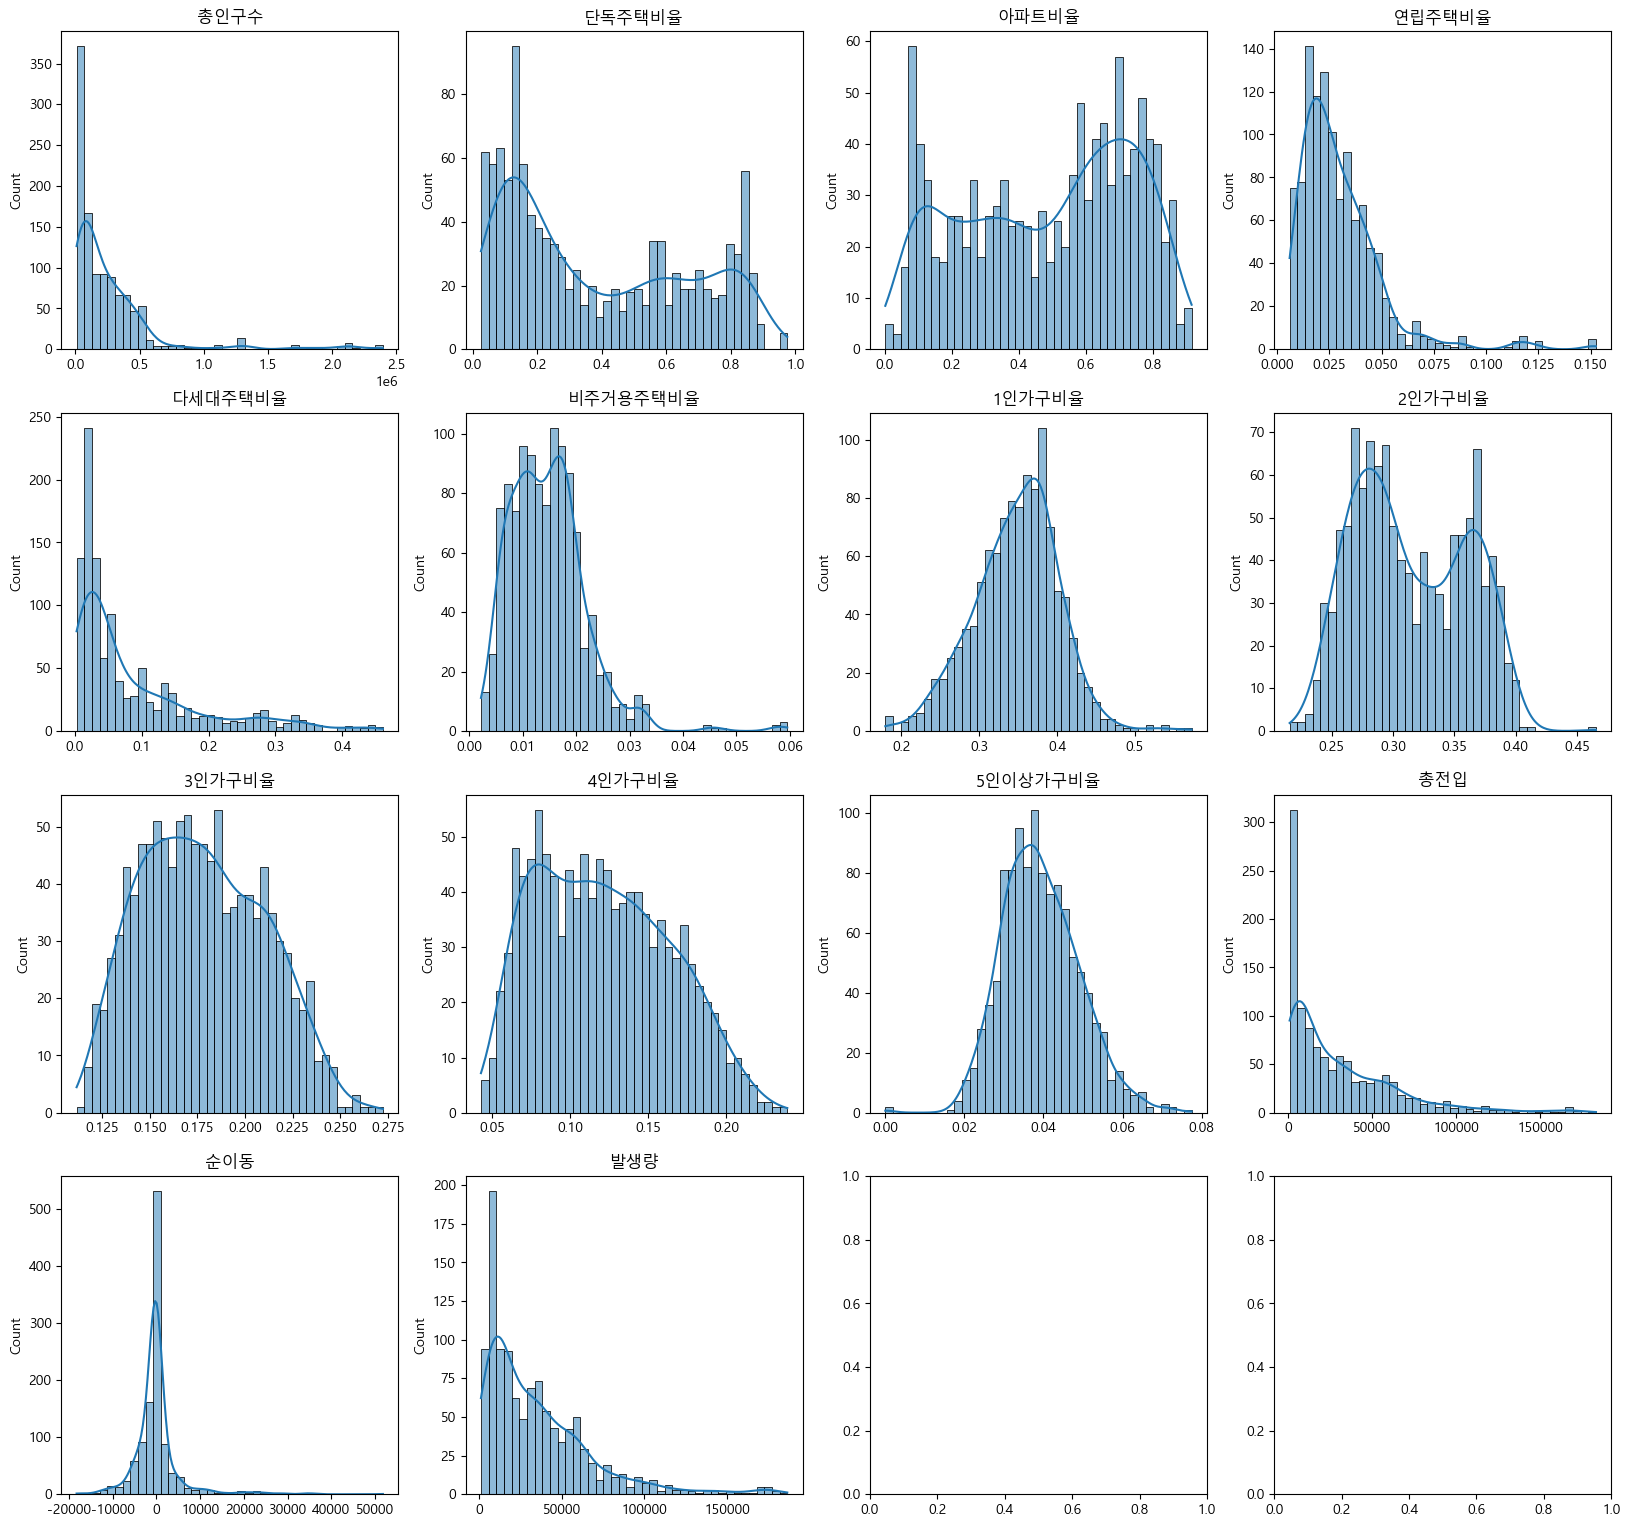

In [41]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 19))
axes = axes.flatten()

for i, column in enumerate(df_merged_1):
    sns.histplot(df_merged_1[column], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_xlabel('')

plt.show()

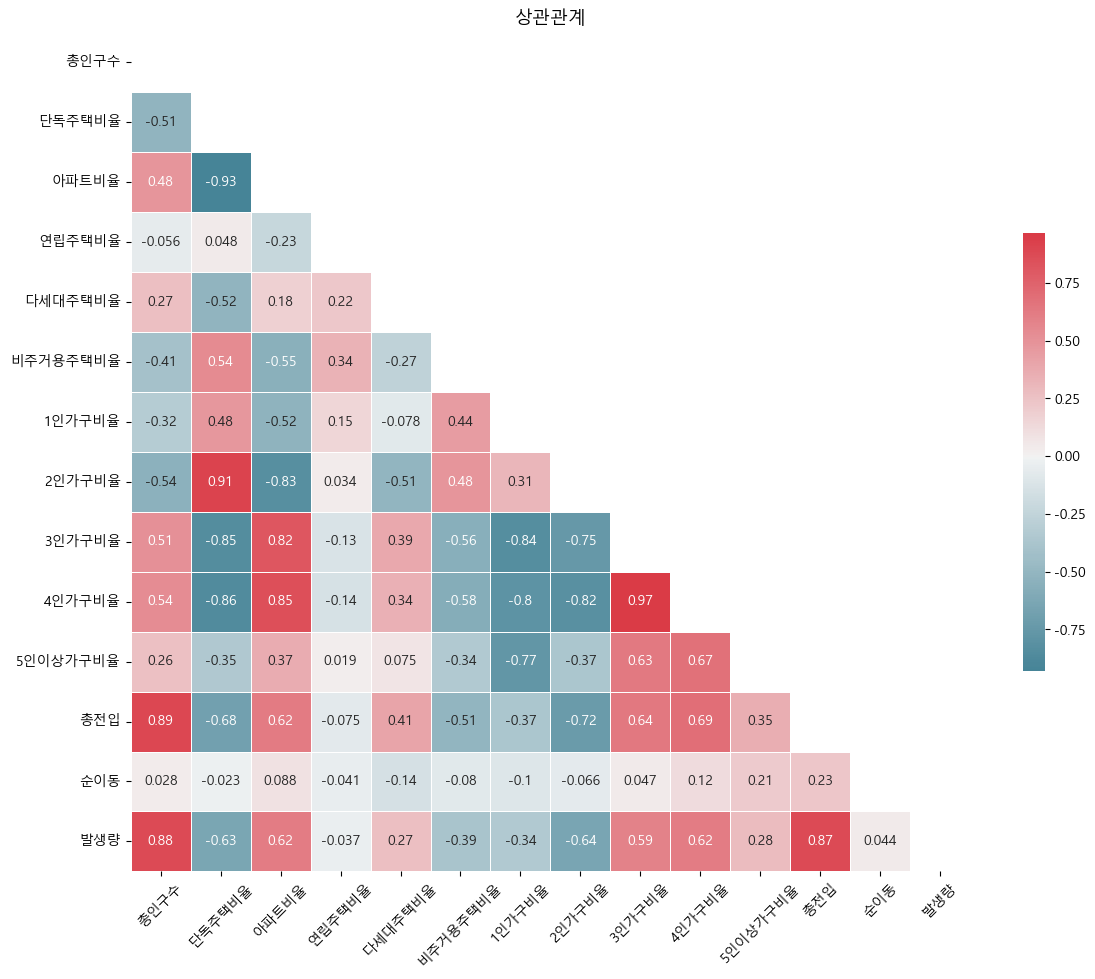

In [42]:
corr = df_merged_1.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool_)) # 하단 삼각형만 남기
f, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(220, 10, as_cmap=True) # color 설
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,square=True,annot=True, linewidths=.5, cbar_kws={"shrink": .5}) # color bar 크기 축소
plt.title('상관관계', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()

# 데이터 전처리
- 회귀용 - 로그변환(x값만), 표준화
- 랜덤포레스트1 - 회귀용데이터로 학습
- 랜덤포레스트2 - raw데이터로 학습

regg (reg 오타났지만 그냥 쓰자!)

In [61]:
df_merged_regg= df_merged_1.copy()
df_merged_rf= df_merged_1.copy()

In [62]:
print(df_merged_regg['총인구수'].describe())
df_merged_regg['ln총인구수'] = np.log(df_merged_regg['총인구수'])
print(df_merged_regg['ln총인구수'].describe())

count    1.128000e+03
mean     2.641857e+05
std      3.701950e+05
min      8.867000e+03
25%      5.096600e+04
50%      1.456575e+05
75%      3.428190e+05
max      2.394514e+06
Name: 총인구수, dtype: float64
count    1128.000000
mean       11.847020
std         1.130975
min         9.090092
25%        10.838912
50%        11.888991
75%        12.744958
max        14.688691
Name: ln총인구수, dtype: float64


In [63]:
print(df_merged_regg['총전입'].describe())
df_merged_regg['ln총전입'] = np.log(df_merged_regg['총전입'])
print(df_merged_regg['ln총전입'].describe())

count      1128.000000
mean      30110.339539
std       32367.519053
min         972.000000
25%        4919.000000
50%       18361.000000
75%       45283.000000
max      183258.000000
Name: 총전입, dtype: float64
count    1128.000000
mean        9.678752
std         1.218991
min         6.879356
25%         8.500860
50%         9.817980
75%        10.720680
max        12.118650
Name: ln총전입, dtype: float64


In [64]:
df_merged_regg = df_merged_regg[['ln총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
       '비주거용주택비율', '1인가구비율', '2인가구비율', '3인가구비율', '4인가구비율', '5인이상가구비율', 'ln총전입',
       '순이동', '발생량']].reset_index()
df_merged_rf.reset_index(inplace=True)

In [66]:
df_merged_regg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   행정구역      1128 non-null   object 
 1   연도        1128 non-null   int64  
 2   ln총인구수    1128 non-null   float64
 3   단독주택비율    1128 non-null   float64
 4   아파트비율     1128 non-null   float64
 5   연립주택비율    1128 non-null   float64
 6   다세대주택비율   1128 non-null   float64
 7   비주거용주택비율  1128 non-null   float64
 8   1인가구비율    1128 non-null   float64
 9   2인가구비율    1128 non-null   float64
 10  3인가구비율    1128 non-null   float64
 11  4인가구비율    1128 non-null   float64
 12  5인이상가구비율  1128 non-null   float64
 13  ln총전입     1128 non-null   float64
 14  순이동       1128 non-null   int64  
 15  발생량       1128 non-null   float64
dtypes: float64(13), int64(2), object(1)
memory usage: 141.1+ KB


# 데이터 split
train, test 비율을 80/20 %   
1128 * 0.8= 902.4  -> 2019-2022  (915)  
1128 * 0.2 = 225.6 -> 2023 (229)   

### linear regression split

In [67]:
reg_x_train = df_merged_regg[df_merged_regg['연도'] != 2023].iloc[:, 2:-1]
reg_y_train = df_merged_regg[df_merged_regg['연도'] != 2023][['발생량']]

reg_x_test = df_merged_regg[df_merged_regg['연도'] == 2023].iloc[:, 2:-1]
reg_y_test = df_merged_regg[df_merged_regg['연도'] == 2023][['발생량']]

- 표준화

In [68]:
scaler = StandardScaler()
# 훈련데이터로 변환
# scaler.fit(reg_x_train)
reg_x_train_s = scaler.fit_transform(reg_x_train)
reg_x_test_s = scaler.transform(reg_x_test)

In [69]:
# 컬럼명 유지
reg_x_train_s = pd.DataFrame(reg_x_train_s, columns = reg_x_train.columns)

reg_x_test_s = pd.DataFrame(reg_x_test_s, columns = reg_x_test.columns)

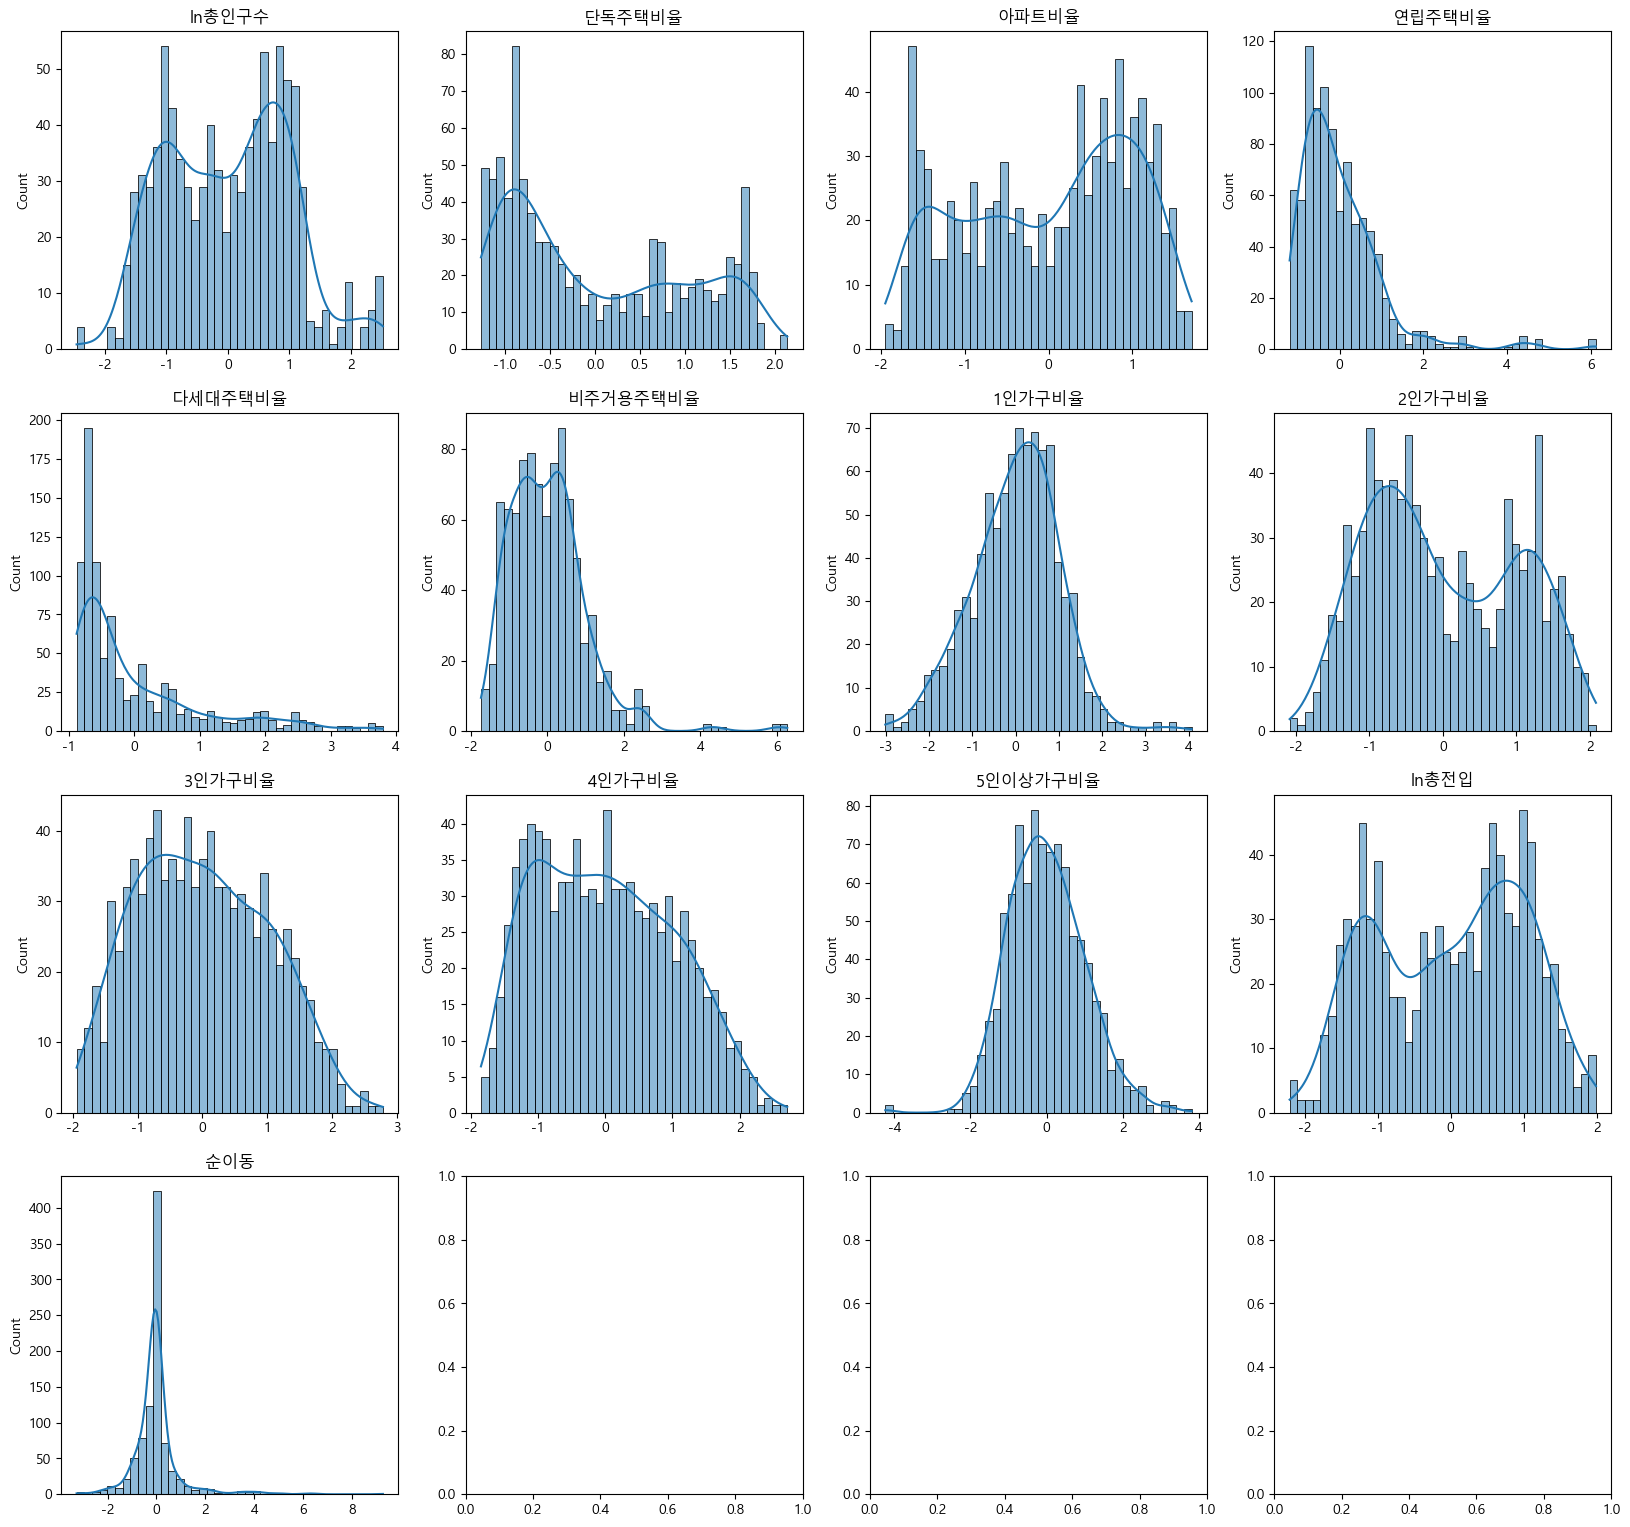

In [70]:
# 히스토그램그리기
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 19))
axes = axes.flatten()

for i, column in enumerate(reg_x_train_s):
    sns.histplot(reg_x_train_s[column], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_xlabel('')

plt.show()

### randomforest split

In [71]:
rf_x_train = df_merged_rf[df_merged_rf['연도'] != 2023].iloc[:, 2:-1]
rf_y_train = df_merged_rf[df_merged_rf['연도'] != 2023][['발생량']]

rf_x_test = df_merged_rf[df_merged_rf['연도'] == 2023].iloc[:, 2:-1]
rf_y_test = df_merged_rf[df_merged_rf['연도'] == 2023][['발생량']]

---

# 랜덤포레스트 비교 - 회귀데이터 vs raw 데이터

In [90]:
randomforest_reg = RandomForestRegressor(random_state=42)
randomforest_reg.fit(reg_x_train_s, reg_y_train)
randomforest_raw = RandomForestRegressor(random_state=42)
randomforest_raw.fit(rf_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
predictions_reg = randomforest_reg.predict(reg_x_test_s)
mse = mean_squared_error(reg_y_test, predictions_reg)
rmse = np.sqrt(mse)
r2 = r2_score(reg_y_test, predictions_reg)
mae = mean_absolute_error(reg_y_test, predictions_reg)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

randomforest_model_performance= {}
randomforest_model_performance["reg_data"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}

predictions_raw = randomforest_raw.predict(rf_x_test)
mse = mean_squared_error(rf_y_test, predictions_raw)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions_raw)
mae = mean_absolute_error(rf_y_test, predictions_raw)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

randomforest_model_performance["raw_data"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}

MSE: 59993959.7970, RMSE: 7745.5768, R^2: 0.9505, MAE: 3900.6897
MSE: 59843724.7176, RMSE: 7735.8726, R^2: 0.9506, MAE: 3880.9996


## 결론
 - raw 데이터가 좋음.

### raw 데이터만 가지고 회귀에서 선정한 피처가 아닌 randomforest에서 피처 선정하기

In [99]:
from itertools import combinations

In [100]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임 x
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = rf_y_train['발생량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            # X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            X_train = X_sub
            X_test = rf_x_test[selected_features]
            
            y_train = y_all
            y_test = rf_y_test['발생량']
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최고 R2 ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['R2'].idxmax()])
    
    return results_df_sorted

In [102]:
rf_x_train.columns

Index(['총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '1인가구비율',
       '2인가구비율', '3인가구비율', '4인가구비율', '5인이상가구비율', '총전입', '순이동'],
      dtype='object')

In [103]:
# feature 리스트 정의
my_selected_features_set1 = [
    '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '1인가구비율',
       '2인가구비율', '3인가구비율', '4인가구비율', '5인이상가구비율', '총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=13
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 13개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/286 완료 - R2: 0.6792, MSE: 388582768.0034
  > 조합 200/286 완료 - R2: 0.8376, MSE: 196707644.0856
  > 조합 286/286 완료 - R2: 0.8288, MSE: 207420743.8720

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/715 완료 - R2: 0.9229, MSE: 93367385.6334
  > 조합 200/715 완료 - R2: 0.9095, MSE: 109635677.0784
  > 조합 300/715 완료 - R2: 0.6052, MSE: 478244263.0453
  > 조합 400/715 완료 - R2: 0.7817, MSE: 264454069.1696
  > 조합 500/715 완료 - R2: 0.6176, MSE: 463277319.9852
  > 조합 600/715 완료 - R2: 0.7726, MSE: 275514110.4855
  > 조합 700/715 완료 - R2: 0.8406, MSE: 193103626.1736
  > 조합 715/715 완료 - R2: 0.8520, MSE: 179323931.9845

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/1287 완료 - R2: 0.9445, MSE: 67215833.5877
  > 조합 200/1287 완료 - R2: 0.9408, MSE: 71668833.3403
  > 조합 300/1287 완료 - R2: 0.9522, MSE: 57907685.6015
  > 조합 400/1287 완료 - R2: 0.9354, MSE: 78288662.7852
  > 조합 500/1287 완료 - R2: 0.7832, MSE: 262598250.0074
  > 조합 600/1287 완료 - R2: 0.6745, MSE: 39430981

,num_features,selected_features,R2,MSE,feature_importances
0,6,"[총인구수, 단독주택비율, 연립주택비율, 다세대주택비율, 1인가구비율, 4인가구비율]",0.955509,5.389795e+07,"[0.8930404285851778, 0.03536414109570666, 0.02..."
1,5,"[총인구수, 아파트비율, 연립주택비율, 다세대주택비율, 4인가구비율]",0.954430,5.520582e+07,"[0.8955237975509309, 0.0288073452747736, 0.023..."
2,7,"[총인구수, 단독주택비율, 연립주택비율, 다세대주택비율, 1인가구비율, 3인가구비율...",0.954087,5.562140e+07,"[0.8923377331235831, 0.03390538047092814, 0.01..."


### 기존 회귀분석에서 선택한 피처 
'ln총인구수', '단독주택비율', '비주거용주택비율', '다세대주택비율', '연립주택비율', '1인가구비율', '2인가구비율'
### randomforest로 선택한 피처
총인구수, 단독주택비율, 연립주택비율, 다세대주택비율, 1인가구비율, 4인가구비율
 
- >비주거용주택비율 빼고 동일!!!
  - 회귀에서 두개차이 보기

In [128]:
final_x_train = rf_x_train[['총인구수', '단독주택비율', '연립주택비율', '다세대주택비율', '1인가구비율', '4인가구비율']]

In [129]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(final_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# - 교차검증해보기

In [130]:
from sklearn.model_selection import cross_val_score

# 튜닝된 모델이 있다면 튜닝된 모델을 사용, 없다면 기본 모델 사용
# model_to_evaluate = model_rf # 튜닝 전
model_to_evaluate = final_model # 튜닝 후

# 5-겹 교차 검증으로 R^2 스코어 계산
# 이때도 OLS에서 선택된 변수들로 구성된 스케일링된 x_train을 사용합니다.
scores = cross_val_score(model_to_evaluate, rf_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

# RMSE도 확인하고 싶다면 scoring을 'neg_mean_squared_error'로 변경 후 sqrt 적용
rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, rf_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [0.91315687 0.96417396 0.95932747 0.9561621  0.95050929]
Mean R^2: 0.9487
Standard deviation of R^2: 0.0183
Cross-validation RMSE scores: [8564.60937424 6202.35086633 6945.17015052 6954.35317387 6550.54999041]
Mean RMSE: 7043.4067
Standard deviation of RMSE: 810.1754


# busan 예측하기 

In [132]:
x_busan = predict_busan[['행정구역','연도', '총인구수', '단독주택비율', '연립주택비율', '다세대주택비율', '1인가구비율', '4인가구비율']].set_index(['행정구역','연도'])
x_busan

,,총인구수,단독주택비율,연립주택비율,다세대주택비율,1인가구비율,4인가구비율
행정구역,연도,,,,,,
부산_강서구,2023,142396,0.1790,0.0068,0.0159,0.305750,0.176826
부산_금정구,2023,215590,0.1773,0.0347,0.2080,0.400460,0.104118
부산_기장군,2023,178729,0.1167,0.0202,0.0554,0.308858,0.152192
부산_남구,2023,254185,0.1380,0.0274,0.2068,0.359557,0.123890
부산_동구,2023,87792,0.3651,0.0282,0.1270,0.435892,0.082502
부산_동래구,2023,270815,0.1136,0.0265,0.1366,0.312375,0.148640
부산_부산진구,2023,359508,0.1352,0.0115,0.1410,0.416489,0.102080
부산_북구,2023,273596,0.0637,0.0210,0.0882,0.316077,0.134569
부산_사상구,2023,202932,0.1126,0.0097,0.1050,0.386925,0.109632


In [134]:
predicted_busan = final_model.predict(x_busan)

In [135]:
predicted_busan

array([21781.747, 29053.355, 27378.295, 28841.453, 13553.293, 28646.495,
       48637.835, 26904.889, 22566.893, 39244.165, 12131.06 , 25704.499,
       24457.405, 12412.132, 15960.777, 46232.305])

In [153]:
predicted_y = predict_busan[['행정구역','연도','총인구수','발생량']]

In [154]:
predicted_y['새로운_발생량'] = predicted_busan

C:\Users\nammi\AppData\Local\Temp\ipykernel_14548\3122906572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['새로운_발생량'] = predicted_busan


In [155]:
predicted_y

,행정구역,연도,총인구수,발생량,새로운_발생량
0,부산_강서구,2023,142396,17160.4,21781.747
1,부산_금정구,2023,215590,32190.5,29053.355
2,부산_기장군,2023,178729,30226.6,27378.295
3,부산_남구,2023,254185,31821.2,28841.453
4,부산_동구,2023,87792,14990.3,13553.293
5,부산_동래구,2023,270815,25182.0,28646.495
6,부산_부산진구,2023,359508,60952.1,48637.835
7,부산_북구,2023,273596,27999.9,26904.889
8,부산_사상구,2023,202932,19262.1,22566.893
9,부산_사하구,2023,297831,40109.1,39244.165


In [156]:
predicted_y['오차(실제값기준)'] = predicted_y['발생량'] - predicted_y['새로운_발생량']

C:\Users\nammi\AppData\Local\Temp\ipykernel_14548\2127832102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['오차(실제값기준)'] = predicted_y['발생량'] - predicted_y['새로운_발생량']


In [145]:
%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']='Malgun Gothic'

C:\Users\nammi\AppData\Local\Temp\ipykernel_14548\1267900333.py:13: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()


c:\workspace\busan\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


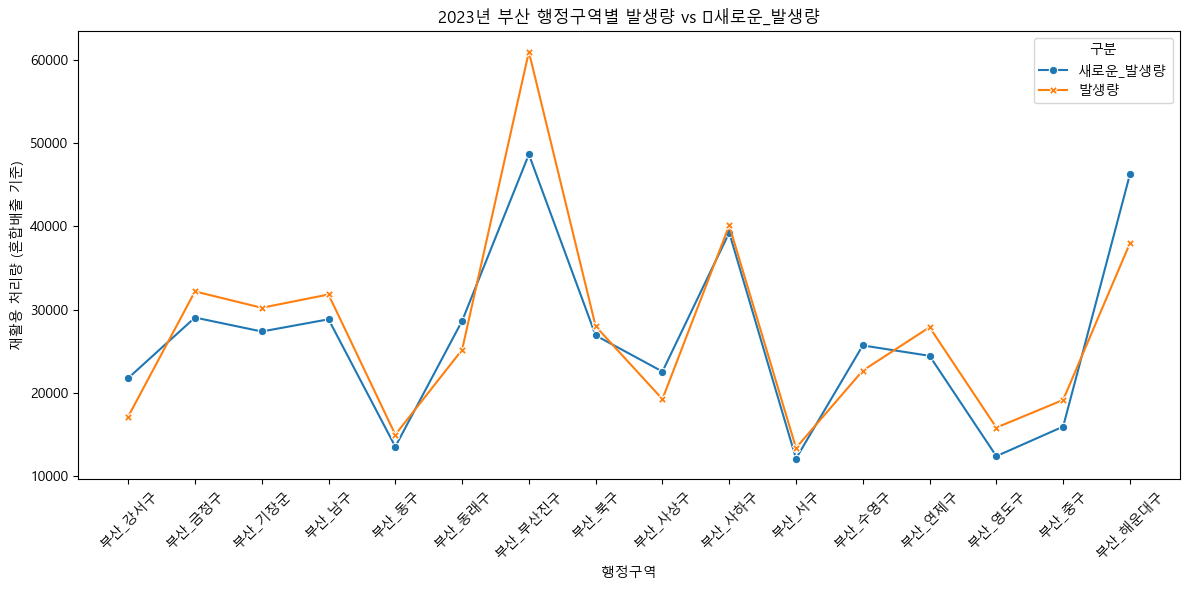

In [146]:
# 시군구별 예측값/실제값 형태 변환
df_plot = predicted_y[['행정구역', '새로운_발생량', '발생량']].melt(id_vars='행정구역', var_name='구분', value_name='값')

# 시군구 이름 기준 정렬
order = predicted_y.sort_values(by='발생량', ascending=False)['행정구역']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='행정구역', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.xticks(rotation=45)
plt.title('2023년 부산 행정구역별 발생량 vs 	새로운_발생량')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('행정구역')
plt.tight_layout()
plt.legend(title='구분')

C:\Users\nammi\AppData\Local\Temp\ipykernel_14548\830023757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')


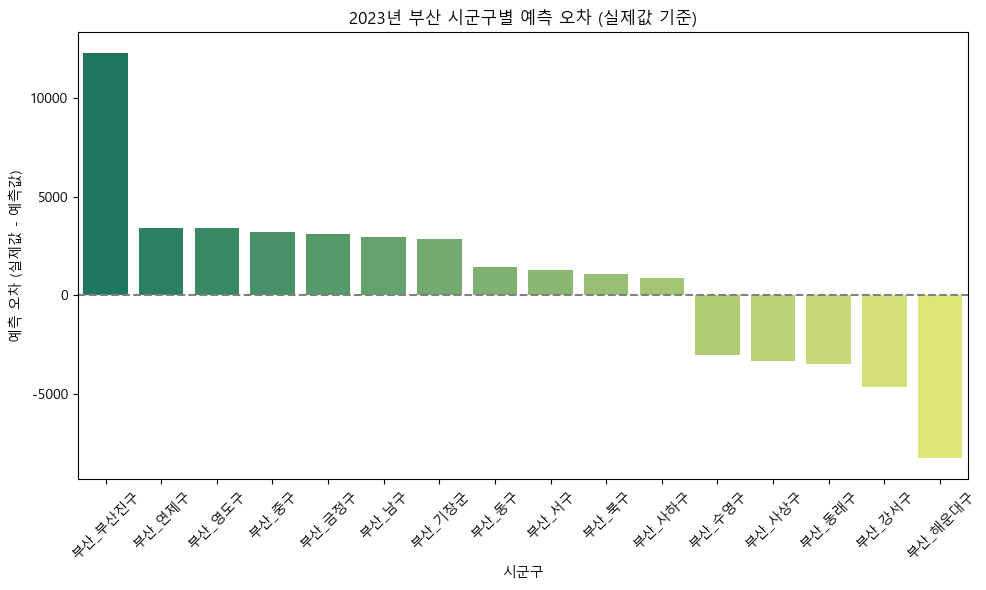

In [147]:

plt.figure(figsize=(10, 6))
df_sorted_heatmap = predicted_y.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()

In [150]:
# 원래는 예측값의 정답은 없지만 확인해보기
mse = mean_squared_error(predicted_y['발생량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['발생량'], predicted_busan)
mae = mean_absolute_error(predicted_y['발생량'], predicted_busan)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 21221961.2721, RMSE: 4606.7300, R^2: 0.8456, MAE: 3667.8238


In [151]:
predicted_y['오차(실제값기준)'].describe()

count       16.000000
mean       833.956375
std       4679.199708
min      -8260.505000
25%      -3091.047500
50%       1354.373500
75%       3153.164500
max      12314.265000
Name: 오차(실제값기준), dtype: float64

In [158]:
# predicted_y.to_csv('../../DB/부산예측2023.csv', encoding='CP949', index=False)

In [168]:
busan_2022 = df_merged[(df_merged['행정구역'].str.startswith('부산_'))&(df_merged['연도']==2022)][['행정구역','연도','총인구수','발생량']]
busan_2022

,행정구역,연도,총인구수,발생량
794,부산_강서구,2022,143207,23876.1
795,부산_금정구,2022,221256,27413.4
796,부산_기장군,2022,178614,26490.4
797,부산_남구,2022,256333,29382.2
798,부산_동구,2022,86462,14765.5
799,부산_동래구,2022,273226,33489.2
800,부산_부산진구,2022,355917,50618.3
801,부산_북구,2022,278857,22925.4
802,부산_사상구,2022,203789,19615.4
803,부산_사하구,2022,301987,41155.4


In [169]:
# busan_2022.to_csv('../../DB/부산비교용2022.csv', encoding='CP949', index=False)